In [1]:
from src.dataloading import EpiConfig, EpiDataOrchestrator, CrossValidationEpiConfig, FoldCollection

In [2]:
cv_config = CrossValidationEpiConfig(
    min_date            = '2014-04-01',
    max_date            = '2024-04-01',
    num_folds           = 6,
    fold_step           = 1,
    train_periods       = 3,
    val_periods         = 1,
    test_periods        = 1,
    expansion_method    = 'rolling_window',
    unit                = 'y'
)


In [3]:
print(cv_config)

 Fold  |    Min Date    |   Train/Val    |    Val/Test    |    Max Date   
--------------------------------------------------------------------------
  0    |   2014-04-01   |   2017-04-01   |   2018-04-01   |   2019-04-01  
  1    |   2015-04-01   |   2018-04-01   |   2019-04-01   |   2020-04-01  
  2    |   2016-04-01   |   2019-04-01   |   2020-04-01   |   2021-04-01  
  3    |   2017-04-01   |   2020-04-01   |   2021-04-01   |   2022-04-01  
  4    |   2018-04-01   |   2021-04-01   |   2022-04-01   |   2023-04-01  
  5    |   2019-04-01   |   2022-04-01   |   2023-04-01   |   2024-04-01  


In [4]:
global_epiconfig = EpiConfig.load_config('default_influenza_quantiles')
global_epiconfig.feature_gisd = False
global_epiconfig.time_index_w = False

fold_collection = FoldCollection.build(cv_config, global_epiconfig)

EpiConfig default_influenza_quantiles loaded


data orchestrator per fold: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:03<00:00,  1.59it/s]


In [5]:
from src.dataloading import BaseLineDataLoaderManager

from src.models import PersistenceModel, ClimateologyModel

In [ ]:
models = {}

for fold_idx, fold in enumerate(fold_collection):

    baseline_data            = BaseLineDataLoaderManager(fold.data_orch)
    
    persistence_predictor   = PersistenceModel(baseline_data,name   = f'fold{fold_idx+1}')
    climateology            = ClimateologyModel(baseline_data,name  = f'fold{fold_idx+1}')


    for ml in [persistence_predictor, climateology]:
        ml.train()
    
    persistence_predictor.forecast('test')
    climateology.forecast('test')

    models_fold = [persistence_predictor,climateology]
    models[f'fold{fold_idx+1}'] = models_fold

In [8]:
# model_evaluations_foldwise 
from src.evaluation import Evaluator

persistences    = []
climateologies  = []


for fold_idx, fold in enumerate(fold_collection):
    for model_idx, model in enumerate(models[f'fold{fold_idx + 1}']):
        if model.__class__.__name__ == 'PersistenceModel':
            persistences.append(model)
        if model.__class__.__name__ == 'ClimateologyModel':
            climateologies.append(model)


evaluators = {
    'persistence':  Evaluator(persistences).add_evaluation(),
    'climateology': Evaluator(climateologies).add_evaluation()
}

figure_raw1 = (evaluators['persistence'].plotter.plot_single_metric('wis',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'persistence', fontweight='bold', fontsize=14)
            )



figure_raw2 = (evaluators['climateology'].plotter.plot_single_metric('wis',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'climateology', fontweight='bold', fontsize=14)
            )


  0%|                                                                                                                                                                                | 0/2400 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2400/2400 [00:01<00:00, 2072.29it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


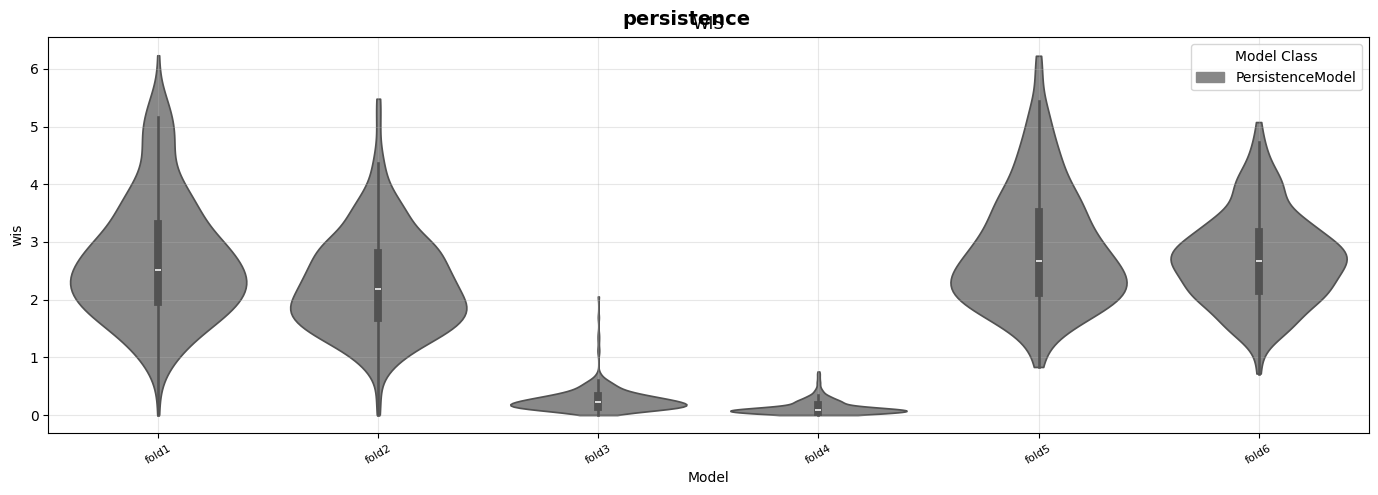

In [9]:
figure_raw1.show()


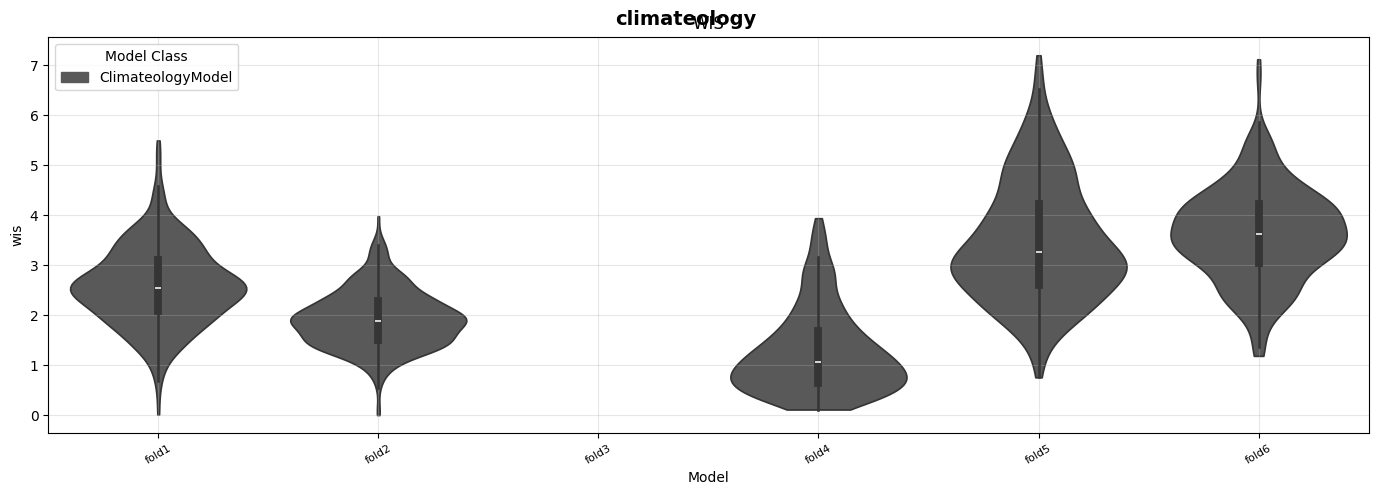

In [10]:
figure_raw2.show()

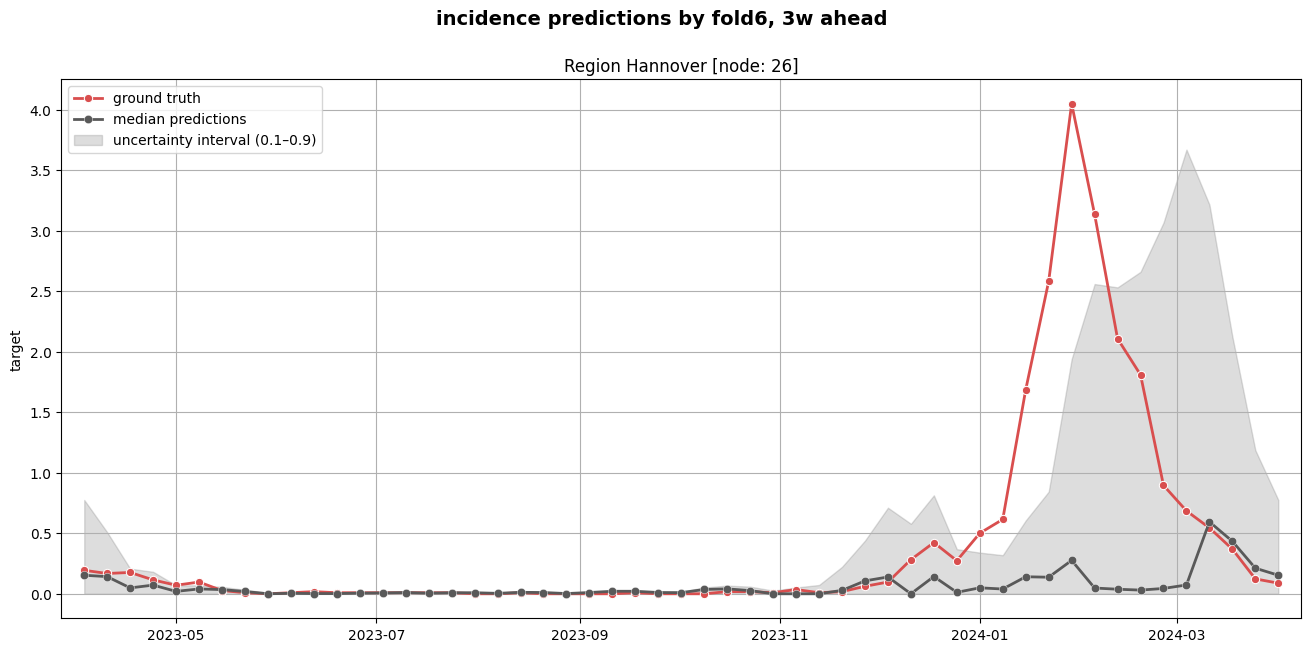

In [16]:
climateologies[5].show_forecasts(26).show()


==           identity_graph_gcn_fold1           ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 20, 4), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.2355   |   3.7850   |    v     |           |
|  002  |   1.1029   |   3.1112   |    v     |           |
|  003  |   0.9874   |   2.6069   |    v     |           |
|  004  |   0.9167   |   2.4234   |    v     |           |
|  005  |   0.8865   |   2.3786   |    v     |           |
|  006  |   0.8690   |   2.3518   |    v     |           |
|  007  |   0.8579   |   2.3245   |    v     |           |
|  008  |   0.8518   |   2.2956   |    v     |           |
|  009  |   0.8397   |   2.2693   |    v     |           |
|  010  |   0.8295   |   2.2431   |    v     |           |
|  011  |   0.8279   |   2.2181   |    v     |           |
|  012  |   0.8162   |   2.1938   |    v

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 1.8641
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 513.76it/s]


Test loss: 1.4819
forecasted ✓

==        geo-neighbors_graph_gcn_fold1         ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 20, 4), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.2428   |   3.6606   |    v     |           |
|  002  |   1.0898   |   2.9231   |    v     |           |
|  003  |   0.9418   |   2.4305   |    v     |           |
|  004  |   0.8620   |   2.2735   |    v     |           |
|  005  |   0.8302   |   2.2614   |    v     |           |
|  006  |   0.8243   |   2.2506   |    v     |           |
|  007  |   0.8136   |   2.2357   |    v     |           |
|  008  |   0.8059   |   2.2234   |    v     |           |
|  009  |   0.8032   |   2.2074   |    v     |           |
|  010  |   0.7984   |   2.1902   |    v     |           |
|  011  |   0.7958   |   2.1756   |    v     |           |
|  012 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 1.8686
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 507.03it/s]


Test loss: 1.5380
forecasted ✓

==           identity_graph_gcn_fold2           ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 20, 4), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.2992   |   1.5892   |    v     |           |
|  002  |   1.1189   |   1.3576   |    v     |           |
|  003  |   0.9780   |   1.1866   |    v     |           |


KeyboardInterrupt: 

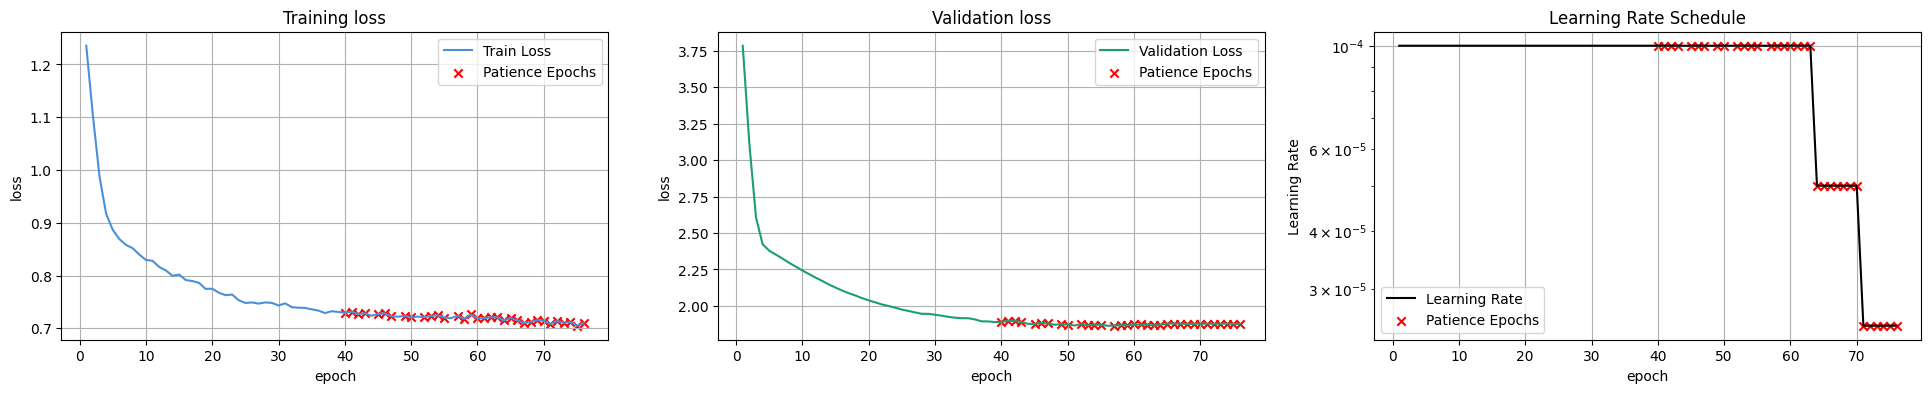

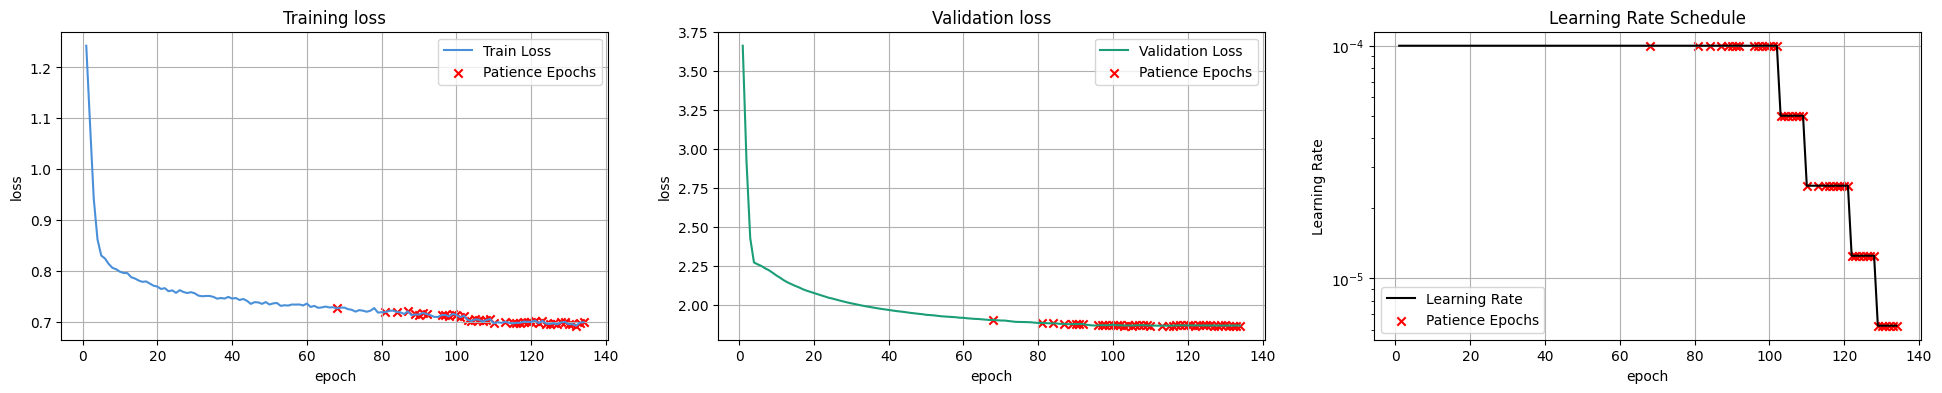

In [19]:
from src.models import SimpleGCNModel
from src.dataloading import GraphDataLoaderManager

n_epochs        = 500
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : 'pinball',
    'patience'          : 20,
    }

deepmodels = {}

for fold_idx, fold in enumerate(fold_collection):
    
    graphloader1            = GraphDataLoaderManager(fold.data_orch).retrieve_static_graph('identity_graph').build()
    gatv1   = SimpleGCNModel(graphloader1,name   = f'identity_graph_gcn_fold{fold_idx+1}', verbose = 2)
    gatv1.set_model_hparams()
    gatv1.set_global_hparams(**global_hparams)
    gatv1.train()
    gatv1.forecast()

    graphloader2            = GraphDataLoaderManager(fold.data_orch).retrieve_static_graph('geographical_neighbors1').build()   
    gatv2   = SimpleGCNModel(graphloader2,name   = f'geo-neighbors_graph_gcn_fold{fold_idx+1}', verbose = 2)
    gatv2.set_model_hparams()
    gatv2.set_global_hparams(**global_hparams)
    gatv2.train()
    gatv2.forecast()


    models_fold = [gatv1,gatv2]
    models[f'fold{fold_idx+1}'] = models_fold

In [17]:
# model_evaluations_foldwise 
from src.evaluation import Evaluator

igs    = []
gns  = []


for fold_idx, fold in enumerate(fold_collection):
    for model_idx, model in enumerate(models[f'fold{fold_idx + 1}']):
        if 'ig_fold' in model.name:
            igs.append(model)
        if 'gn_fold' in model.name:
            gns.append(model)

evaluators = {
    'ig':  Evaluator(igs).add_evaluation(),
    'gn': Evaluator(gns).add_evaluation()
}

figure_raw1 = (evaluators['ig'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'identity graph', fontweight='bold', fontsize=14)
            )



figure_raw2 = (evaluators['gn'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'geographical neighbors', fontweight='bold', fontsize=14)
            )


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3600/3600 [00:04<00:00, 837.22it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


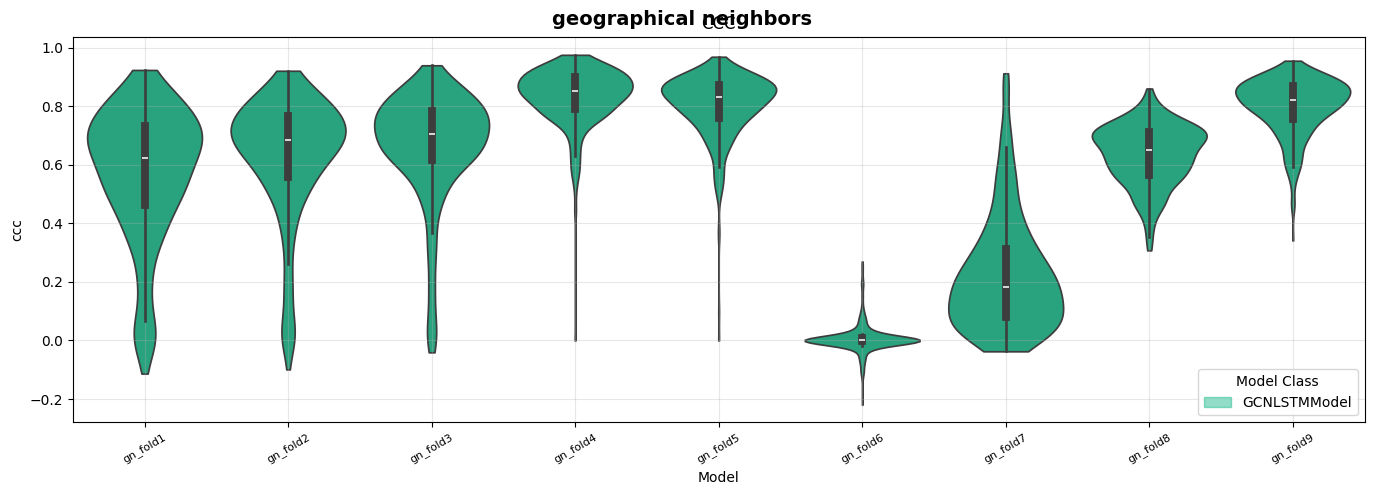

In [18]:
figure_raw2.show()

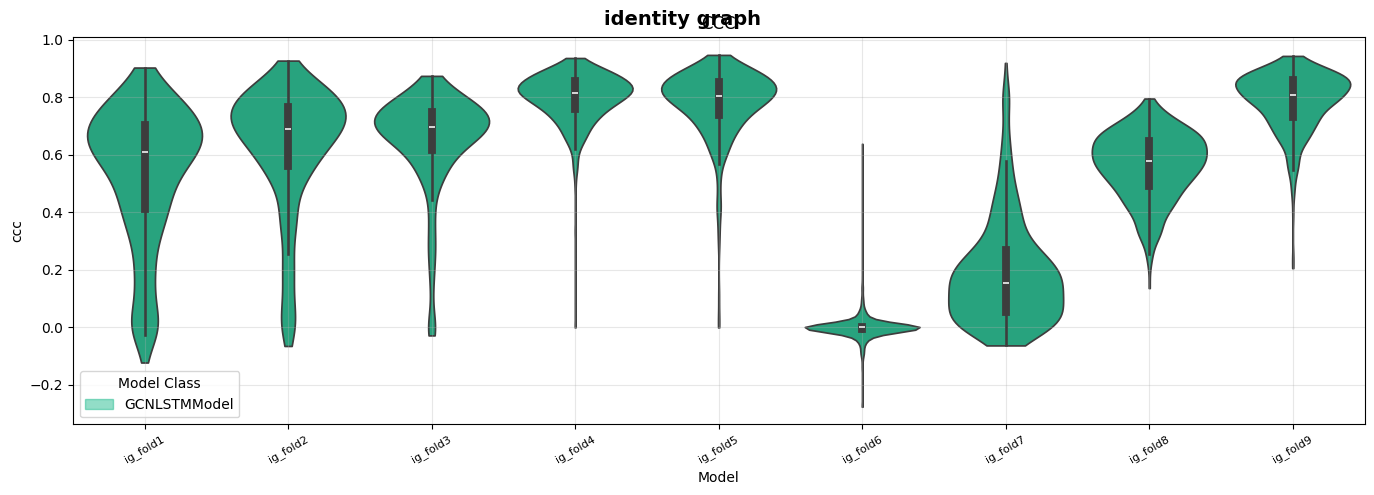

In [19]:
figure_raw1.show()

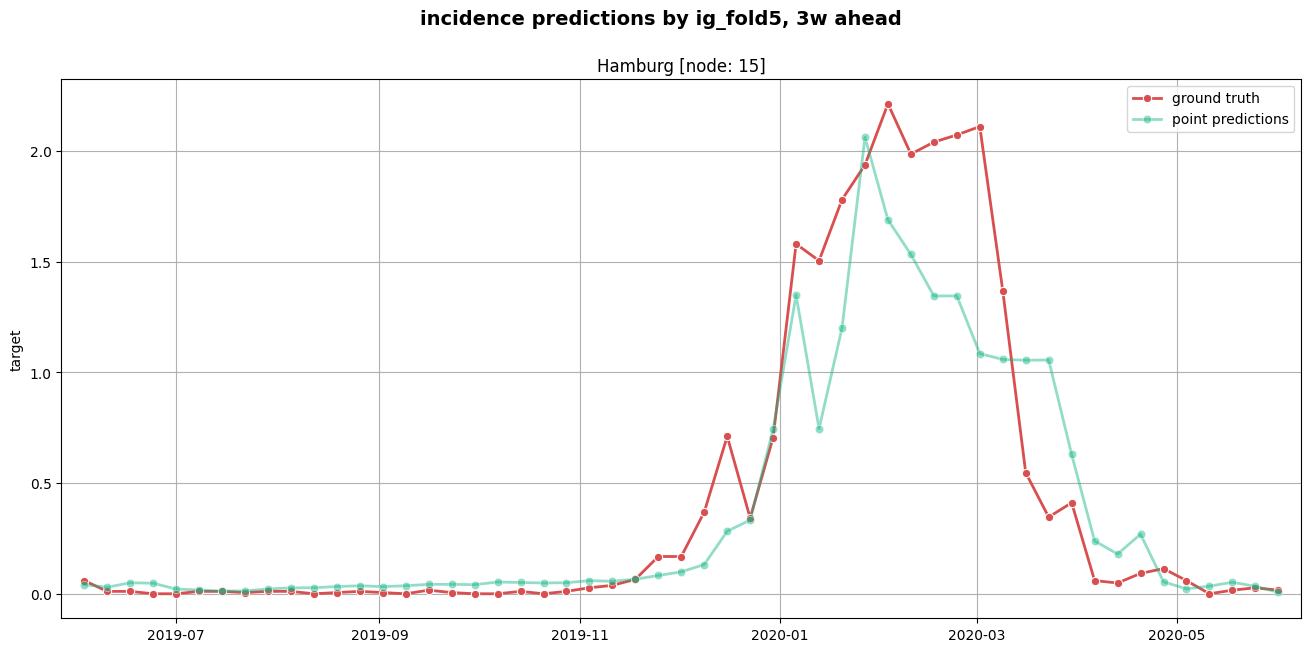

In [29]:
igs[4].show_forecasts(15).show()

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


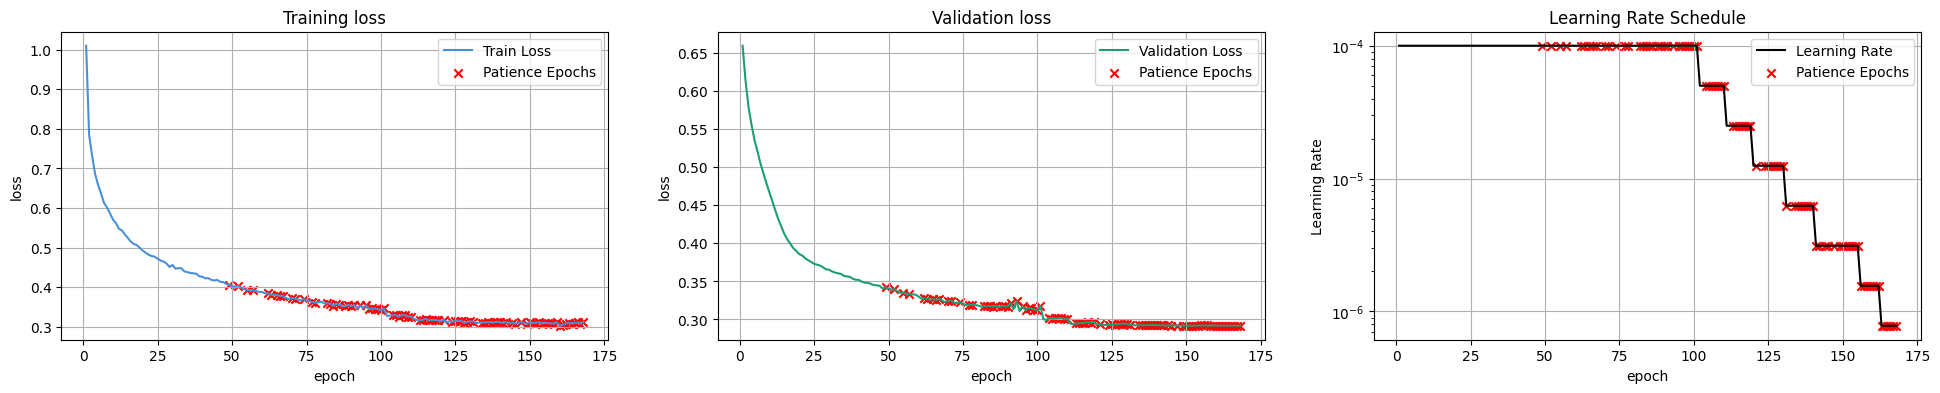

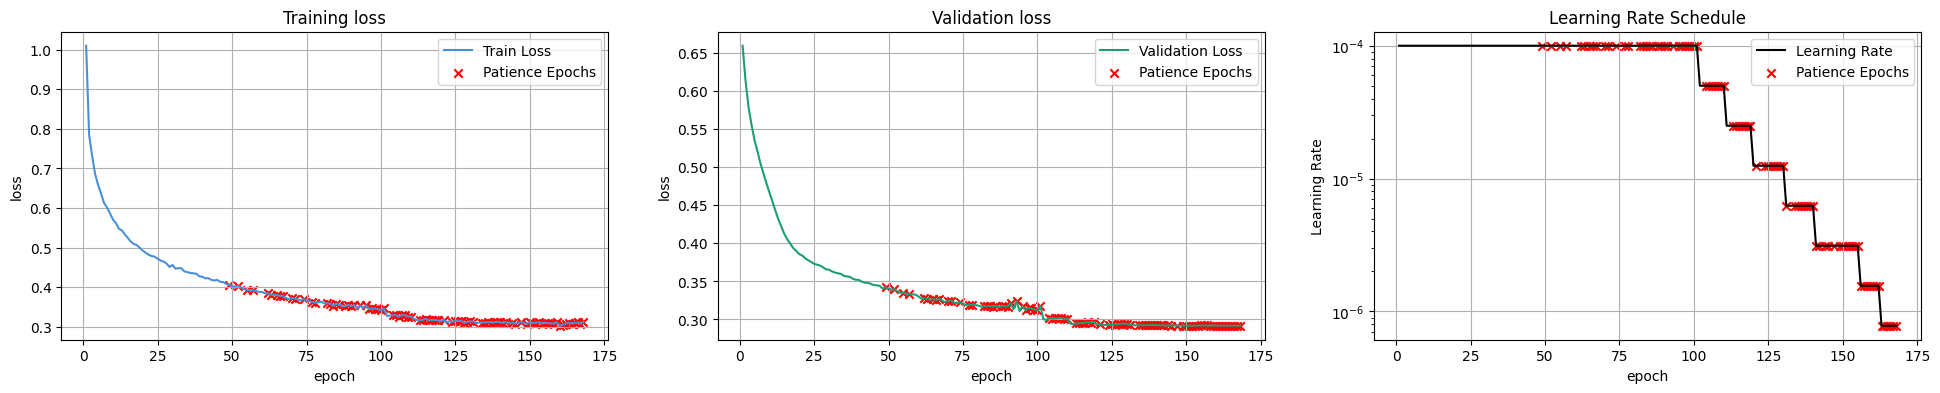

In [27]:
gns[5].show_monitoring_metrics()